Libraries

In [1]:
#joonwon@asgard:~/isaac-lab$ 
# ./isaaclab.sh -p scripts/reinforcement_learning/rsl_rl/play_koopman.py --task=Isaac-Velocity-Rough-Anymal-C-v0 --num_env=100 --model=temp6

import os
import sys
sys.path.append('/dataset/')
sys.path.append("../src_re") 

import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import parameters_to_vector
from scipy.linalg import eig, inv
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.stateless import functional_call
from tensorboard import notebook
from datetime import datetime
from tqdm import tqdm
import wandb

# KAE
from Autoencoder import KoopmanAutoencoder_walk
from Autoencoder_functions import *
# from Autoencoder import Original_network
from state_extract import *

# # Cartpole
# from test_cartpole_function import *
# from models.MLP import CartpoleMLP



Parameters

In [ ]:
# Use GPU
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:1')
print('Currently using... '+str(device))

# Load pre-trained KAE?
load_model = False
load_model_name = 'test2.pth'

# KAE parameters
observable_dim = 128 # observable dim
padded_dimension = 256 # MUST BE BIGGER THAN ANY STATE DIMENSION (INPUT, OUPTUT, INTERNAL)
kae_size = 512 # size of KAE
c1, c2, c3 = 1, 1, 1 # KAE loss parameters
p = 2 # KAE prediction step
loss_dist_mc_sample_num = 5 # number of MC integral samples
### -------------------- Loss coefficient
kae_coef = 0.3 # 0.3
action_coef = 0.7 # 0.7
# task_coef = 1/10000
task_coef = -1 # NO LOSS_TASK NOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
eig_coef = -1
dist_coef = -1

# Data & Training parameter
training_data_generation_loop = 100000 # how many loop you will run to generate the data
                                      # NOT NUMBER OF TRAINING DATA: that is 'training_data_size'
validation_data_generation_loop = 1000 # how many loop you will run to generate the data
                                      # NOT NUMBER OF TRAINING DATA: that is 'training_data_size'                                  
batch_size = 2048 # 128
lr_kae = 1e-3
schedule_it = 300
lr_kae2 = 1e-4
schedule_it2 = 5000
lr_kae3 = 1e-6
num_epochs = 10000
# num_episodes_for_loss_task = -1 # test number during training (=validation set)
# waypoint_period = 5 # Check score every this epoch and update waypoint
# check_performance = False # Check performance before update the waypoint?
clip = True # clip gradient norm?
clip_bound = 1.0
pad_one = True # pad with 1?
load_actual_data = False # load actual walking data?

# Original network parameters
original_model_dict = torch.load("results/walking_policy_new.pth", weights_only=False)
original_model = original_model_dict["actor"]
original_model.to(device)
original_model.eval()

# Initialization
training_data_size = training_data_generation_loop*p # size of training dataset
validation_data_size = validation_data_generation_loop*p # size of training dataset
obs_dim = 235
act_dim = 12
Info = [observable_dim, padded_dimension, kae_size, kae_coef, eig_coef, dist_coef, p, 'walk_v0']

# Input bound
# scale_factor = 1.3
# state_bound_file = np.load('results/policy_io_data_max_min.npy', allow_pickle=True)
# state_bound_data = state_bound_file.item()
# state_bound_min = state_bound_data['min']
# state_bound_max = state_bound_data['max']

# state_bound_min = np.abs(state_bound_min) * scale_factor * np.sign(state_bound_min)
# state_bound_max = np.abs(state_bound_max) * scale_factor * np.sign(state_bound_max)

# state_bound_lo = torch.from_numpy(state_bound_min).to(device)
# state_bound_hi = torch.from_numpy(state_bound_max).to(device)
# # state_bound_lo = -10*torch.ones(obs_dim, device=device) 
# # state_bound_hi = 10*torch.ones(obs_dim, device=device) 
# act_bounds = torch.load("results/act_bound.pt")
# act_lo = act_bounds["min"].to(device)
# act_hi = act_bounds["max"].to(device)
state_bound_lo = -1.5*torch.ones(obs_dim, device=device) 
state_bound_hi = 1.5*torch.ones(obs_dim, device=device) 


# TEST SECTION
print((state_bound_hi[0]))
print('obs dim: '+str(obs_dim) + ' / act dim: '+str(act_dim))
if padded_dimension < obs_dim or padded_dimension < act_dim:
    print('ERROR, PADDED DIMENSION MUST BE BIGGER')
    exit()

assert batch_size%p==0, "batch size must be divisible by p"

print(original_model)

Currently using... cuda:1
tensor(1.5000, device='cuda:1')
obs dim: 235 / act dim: 12
MLP(
  (0): Linear(in_features=235, out_features=512, bias=True)
  (1): ELU(alpha=1.0)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ELU(alpha=1.0)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ELU(alpha=1.0)
  (6): Linear(in_features=128, out_features=12, bias=True)
)


Fixed parameters & Initialization

In [3]:
## Set training to be deterministic
seed = 10
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

## GENERATE RANDOM SAMPLE FOR KAE TRAINING
if load_actual_data:
    with torch.no_grad():
                training_data = []
                if p == 1:
                    inputs = []
                    with open("results/obs_log.pkl", "rb") as f:
                        while True:
                            try:
                                inputs.append(pickle.load(f))
                            except EOFError:
                                break          

                    outputs = []
                    with open("results/act_log.pkl", "rb") as f:
                        while True:
                            try:
                                outputs.append(pickle.load(f))
                            except EOFError:
                                break  

                    print("data len: " + str(len(inputs)))
                    data_len = len(inputs)

                    for data_in, data_out in zip(inputs, outputs):
                        # data_in:  [100, obs_dim]
                        # data_out: [100, act_dim]

                        for i in range(data_in.size(0)):         # loop over 100 samples
                            x  = data_in[i:i+1].to(device)       # [1, obs_dim]
                            y  = data_out[i:i+1].to(device)      # [1, act_dim]

                            # EXACT same padding behavior as your original code
                            if pad_one:
                                pad_in  = torch.ones(1, padded_dimension - obs_dim, device=device)
                                pad_out = torch.ones(1, padded_dimension - act_dim, device=device)
                            else:
                                pad_in  = torch.zeros(1, padded_dimension - obs_dim, device=device)
                                pad_out = torch.zeros(1, padded_dimension - act_dim, device=device)

                            aug_input  = torch.cat([x, pad_in], dim=1)   # [1, padded_dim]
                            aug_output = torch.cat([y, pad_out], dim=1)  # [1, padded_dim]

                            training_data.append((aug_input.cpu(), aug_output.cpu()))

                else:
                    print("CURRENTLY P==1 ONLY")

else:
    # LOAD existing dataset
    if os.path.isfile('results/walk_training_samples_'+str(int(training_data_size))+'_p_'+str(p)+'.pth'):
        data_dict = torch.load('results/walk_training_samples_'+str(int(training_data_size))+'_p_'+str(p)+'.pth', map_location=device)
        training_data = data_dict['training_data']
        print('dataset loaded')
    else:
        with torch.no_grad():
            training_data = []
            for i in range(training_data_generation_loop):
                random_input = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
                # random_input = torch.empty(1, obs_dim, device=device).uniform_(state_bound_lo, state_bound_hi)
                random_input.to(device)

                if p == 1:
                    outputs = original_model(random_input)            
                    if pad_one:
                        pad_in = torch.ones(random_input.size(0), padded_dimension - obs_dim, device=device)
                        pad_out = torch.ones(outputs.size(0), padded_dimension - act_dim, device=device)
                    else:
                        pad_in = torch.zeros(random_input.size(0), padded_dimension - obs_dim, device=device)
                        pad_out = torch.zeros(outputs.size(0), padded_dimension - act_dim, device=device)
                    aug_input = torch.cat([random_input, pad_in], dim=1)
                    aug_output = torch.cat([outputs, pad_out], dim=1)

                    # Save snapshot
                    training_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))
                    # print(np.shape(training_data))

                else:
                    states = p_state_extract(original_model, random_input, p=p)
                    # organize states in order: input → step_1 → step_2 → ... → output
                    state_seq = [states["input"]]

                    for k in sorted([k for k in states.keys() if k.startswith("step_")],
                                    key=lambda x: int(x.split("_")[1])):
                        state_seq.append(states[k])
                    state_seq.append(states["output"])

                    # build dataset: (s_i, s_{i+1})
                    for j in range(len(state_seq) - 1):
                        s_in, s_out = state_seq[j], state_seq[j+1]

                        if s_in.size(1) > padded_dimension or s_out.size(1) > padded_dimension:
                            print("padded_dimension is too small. Internal state dims are: ", s_in.size(1)," and ", s_out.size(1))
                            # break

                        if pad_one:
                            pad_in = torch.ones(s_in.size(0), padded_dimension - s_in.size(1), device=device)
                            pad_out = torch.ones(s_out.size(0), padded_dimension - s_out.size(1), device=device)
                        else: 
                            pad_in = torch.zeros(s_in.size(0), padded_dimension - s_in.size(1), device=device)
                            pad_out = torch.zeros(s_out.size(0), padded_dimension - s_out.size(1), device=device)

                        aug_input = torch.cat([s_in, pad_in], dim=1)
                        aug_output = torch.cat([s_out, pad_out], dim=1)

                        training_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

        # Save the generated training data
        torch.save({'training_data': training_data}, 'results/walk_training_samples_'+str(int(training_data_size))+'_p_'+str(p)+'.pth')
        print('dataset generated')
        
# print(np.shape(training_data))

## Build KAE
state_dim = padded_dimension
kae = KoopmanAutoencoder_walk(state_dim=state_dim, hidden_dim=kae_size, observable_dim = observable_dim, device=device).to(device)
# kae.train()
criterion_kae = koopman_loss
mse = torch.nn.MSELoss()
optimizer_kae = optim.Adam(kae.parameters(), lr=lr_kae)
kae.train()


print(f"Total samples: {len(training_data)}")
# print(type(training_data))
test = training_data
# print(training_data[0][1].shape)
# assert(training_data_size == len(training_data)), "data size is wrong check it."
for i, (inp, out) in enumerate(training_data[:5]):  # show first 5
    print(f"Sample {i}: input {inp.shape}, output {out.shape}")

dataset loaded
walking Tanh ver
Total samples: 100000
Sample 0: input torch.Size([1, 256]), output torch.Size([1, 256])
Sample 1: input torch.Size([1, 256]), output torch.Size([1, 256])
Sample 2: input torch.Size([1, 256]), output torch.Size([1, 256])
Sample 3: input torch.Size([1, 256]), output torch.Size([1, 256])
Sample 4: input torch.Size([1, 256]), output torch.Size([1, 256])


Plot training data & check bound

Plotting 100000 samples (p = 2)


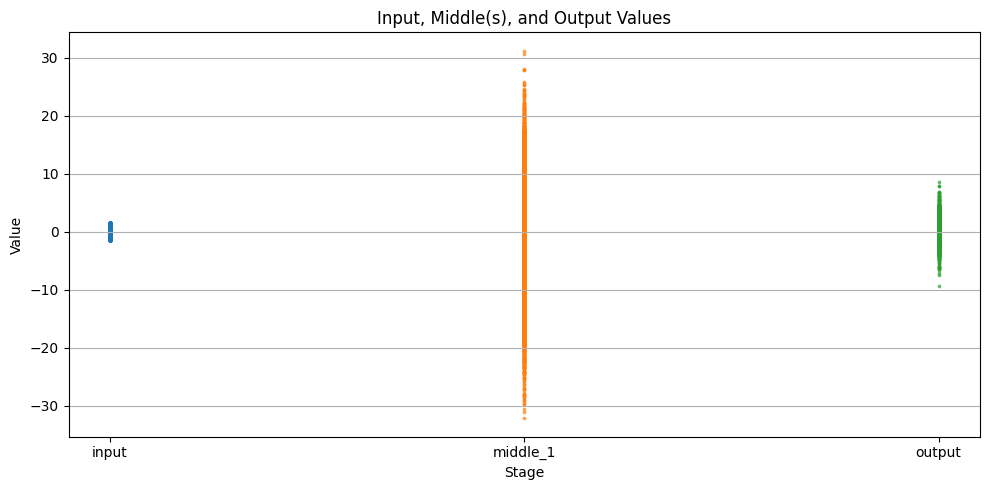

MLP(
  (0): Linear(in_features=235, out_features=512, bias=True)
  (1): ELU(alpha=1.0)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ELU(alpha=1.0)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ELU(alpha=1.0)
  (6): Linear(in_features=128, out_features=12, bias=True)
)


In [4]:
import matplotlib.pyplot as plt
import torch

# assumes training_data and p already exist
print(f"Plotting {len(training_data)} samples (p = {p})")

categories = ["input"] + [f"middle_{i+1}" for i in range(p-1)] + ["output"]
x_labels = list(range(len(categories)))
all_values = {label: [] for label in categories}

# collect all data by stage
for i in range(0, 100*p, p):
    seq_pairs = training_data[i:i+p]
    states = [seq_pairs[0][0]]
    for pair in seq_pairs:
        states.append(pair[1])
    states = [s.detach().cpu().flatten() for s in states]

    for label, tensor in zip(categories, states):
        all_values[label].extend(tensor.tolist())

# flatten all for plotting
plt.figure(figsize=(10,5))
for j, label in enumerate(categories):
    plt.scatter([j]*len(all_values[label]), all_values[label], s=3, alpha=0.6)

plt.xticks(x_labels, categories)
plt.title("Input, Middle(s), and Output Values")
plt.xlabel("Stage")
plt.ylabel("Value")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(original_model)

Wandb

In [5]:
# Connect wandb
current_date = datetime.now().strftime("%Y-%m-%d")

wandb.init(project="Koopman_decomposition_walk",
           name = str(current_date),
           config={
            "lr_kae": lr_kae,
            "num_epochs": num_epochs,
            "batch_size": batch_size,
            "p": p,
            "c1": c1,
            "c2": c2,
            "c3": c3,
            "training_data_size": training_data_size,
            'Info': Info,
            'observable_dim': observable_dim,
            'padded_dimension': padded_dimension,
            'kae_size': kae_size,
            'kae_coef': kae_coef,
            'task_coef': task_coef,
            'eig_coef': eig_coef,
            'dist_coef': dist_coef,
            'action_coef': action_coef,
            'training_data_generation_loop': training_data_generation_loop,
            'batch_size': batch_size,
        #     'num_episodes_for_loss_task': num_episodes_for_loss_task,
            'loss_dist_mc_sample_num': loss_dist_mc_sample_num
    })

wandb: Currently logged in as: choi774 (choi774-purdue-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Main training

In [6]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from Autoencoder import *
from Autoencoder_functions import *
from test_cartpole_function import *

## Preprocess KAE train data
train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=False)
aug_input_all = torch.cat([training_data[i][0].unsqueeze(0) for i in range(len(training_data))]).to(device)
aug_output_all = torch.cat([training_data[i][1].unsqueeze(0) for i in range(len(training_data))]).to(device)
print(np.shape(aug_input_all))

# Load model
if load_model:
    kae = torch.load('results/'+load_model_name, weights_only=False, map_location=device)
    # kae.load_state_dict(torch.load("results/"+load_model_name))
    kae.to(device)
    kae.eval()
    print('model loaded')

# Or train new one
elif not load_model:
    waypoint_epoch = 0
    best_reward = 0.0
    avg_loss_past = torch.inf
    for epoch in (tq_var := tqdm(range(num_epochs), desc="Training")):
        running_loss = 0.0
        running_classifier_loss = 0.0

        if epoch > schedule_it:
            lr_kae = lr_kae2
        if epoch > schedule_it2:
            lr_kae = lr_kae3

        # Each batch
        for inner, (aug_input, aug_output) in enumerate(train_loader):
            # print(aug_input.shape, aug_output.shape)
            loss_task = 0.0
            loss_kae = 0.0
            loss_eig = 0.0
            loss_dist = 0.0
            loss_action = 0.0

            # KAE loss, Action loss
            if kae_coef > 0:
                loss_kae, loss_action = compute_l_kae(kae, aug_input, aug_output, c1, c2, c3, p, 
                                device, aug_input_all, aug_output_all, inner, batch_size, act_dim)
                if action_coef < 0:
                    loss_action = 0.0

            # # Task loss
            # if task_coef > 0:
            #     # loss_task = compute_l_task(kae, aug_input, aug_output, mse, device)
            #     reward_loss_task = test_cartpole_kae_function(kae, observable_dim, padded_dimension, p, device, mode_number = -1, num_episodes = num_episodes_for_loss_task, save_imgs = False)
            #     loss_task = ((reward_loss_task - max_reward)**2)

            # Eigenvalue loss
            if eig_coef > 0:
                current_K = kae.K.to(device)
                current_eig, _ = torch.linalg.eig(current_K)
                current_eig_mag = torch.abs(current_eig).to(device)
                loss_eig = mse(current_eig_mag, torch.ones(observable_dim).to(device))           

            # Mode distance loss - MC integral based orthogonality
            if dist_coef > 0:
                current_K = kae.K.to(device)
                current_eig, _ = torch.linalg.eig(current_K)
                current_eig_mag = torch.abs(current_eig).to(device)
                loss_dist = compute_l_dist(observable_dim, current_eig, loss_dist_mc_sample_num, obs_dim, state_bound_lo, state_bound_hi, 
                   padded_dimension, p, kae, device)

            # Total loss
            loss = kae_coef * loss_kae + task_coef * loss_task + eig_coef * loss_eig + dist_coef * loss_dist + action_coef * loss_action

            # Update           
            optimizer_kae.zero_grad()
            loss.backward()
            # print(any(p.grad is None for p in kae.parameters()))
            if clip:
                torch.nn.utils.clip_grad_norm_(kae.parameters(), max_norm=clip_bound)  # Add this line here
            optimizer_kae.step()
            running_loss = running_loss + loss.detach().cpu().item()

            _, latent_x_all, _ = kae(aug_input_all)
            _, latent_y_all, _ = kae(aug_output_all)
            latent_x_all = latent_x_all.to(device)
            latent_y_all = latent_y_all.to(device)
            kae.compute_koopman_operator(latent_x_all, latent_y_all, device)

            # _, latent_x, _ = kae(aug_input)
            # _, latent_y, _ = kae(aug_output)
            # latent_x = latent_x.to(device)
            # latent_y = latent_y.to(device)
            # kae.compute_koopman_operator(latent_x, latent_y, device)

        # print(latent_x_all.size())
        if latent_x_all.dim() == 3:
            rank = torch.linalg.matrix_rank(latent_x_all[:,0,:].detach())
            cond = torch.linalg.cond(latent_x_all[:,0,:].detach().T @ latent_x_all[:,0,:].detach())
        else: 
            rank = torch.linalg.matrix_rank(latent_x_all.detach())
            cond = torch.linalg.cond(latent_x_all.detach().T @ latent_x_all.detach())
            # print(f"latent rank: {rank}/{latent_x_all.shape[1]},  cond={cond:.2e}")

        current_date = datetime.now().strftime("%Y-%m-%d") 
        waypoint_name = 'waypoints/waypoint_v2_'+str(Info)+f'_{current_date}.pth'
        file_name = 'waypoints/KAE_v2_'+str(Info)+f'_{current_date}.pth'
        file_name_state_dict = 'waypoints/KAE_state_dict_'+str(Info)+f'_{current_date}.pt'
        avg_loss = running_loss / len(train_loader)
        # tq_var.set_description(f'Epoch [{epoch+1:4d}/{num_epochs}] | r&c:{rank}/{observable_dim}-{cond:.2e} | Loss: {avg_loss:.3f} | loss_kae: {loss_kae:.2f} | loss_eig {loss_eig:.2f} | loss_dist {loss_dist:.2f} | saved at {waypoint_epoch:.0f}')
        tq_var.set_description(f'Epoch [{epoch+1:4d}/{num_epochs}] | r&c:{rank}/{observable_dim}-{cond:.2e} | Loss: {avg_loss:.3f} | loss_kae: {kae_coef * loss_kae:.3f} | loss_action: {action_coef * loss_action:.4f} | saved at {waypoint_epoch:.0f}')

        # Wandb
        wandb.log({
            "epoch": epoch,
            "train_loss": running_loss,
            "avg_loss": avg_loss,
            "loss_kae": loss_kae,
            "loss_task": loss_task,
            "loss_eig": loss_eig,
            "loss_dist": loss_dist,
            "loss_action": loss_action,
            "lr": lr_kae
        })

        if (avg_loss < avg_loss_past):
            torch.save({
            'epoch': epoch,
            'param_kae': kae.state_dict(),
            'optimizer_state_dict': optimizer_kae.state_dict(),
            'ko': kae.K,
            'Info': Info,
            'observable_dim': observable_dim,
            'padded_dimension': padded_dimension,
            'kae_size': kae_size,
            'kae_coef': kae_coef,
            'task_coef': task_coef,
            'eig_coef': eig_coef,
            'dist_coef': dist_coef,
            'action_coef': action_coef,
            'lr_kae': lr_kae,
            'training_data_generation_loop': training_data_generation_loop,
            'batch_size': batch_size,
            'c1': c1, 'c2': c2, 'c3': c3, 'p': p,
            # 'num_episodes_for_loss_task': num_episodes_for_loss_task,
            'loss_dist_mc_sample_num': loss_dist_mc_sample_num
            }, waypoint_name)
            torch.save(kae, file_name)
            torch.save(kae.state_dict(), file_name_state_dict)
            avg_loss_past = avg_loss
            # tqdm.write(f"Epoch {epoch}: checkpoint saved.")
            waypoint_epoch = epoch
            # print("New waypoin saved wo validation")

        if math.isnan(running_loss/len(train_loader)):
            print('NAN detected')
            break
            
    current_date = datetime.now().strftime("%Y-%m-%d")
    waypoint_name = 'results/waypoint_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    file_name = 'results/KAE_v2_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    file_name_state_dict = 'results/KAE_v2_state_dict_'+str(Info)+f'_{current_date}.pt'
    torch.save({
    'epoch': epoch,
    'param_kae': kae.state_dict(),
    'optimizer_state_dict': optimizer_kae.state_dict(),
    'ko': kae.K,
    'Info': Info,
    'observable_dim': observable_dim,
    'padded_dimension': padded_dimension,
    'kae_size': kae_size,
    'kae_coef': kae_coef,
    'task_coef': task_coef,
    'eig_coef': eig_coef,
    'dist_coef': dist_coef,
    'action_coef': action_coef,
    'lr_kae': lr_kae,
    'training_data_generation_loop': training_data_generation_loop,
    'batch_size': batch_size,
    'c1': c1, 'c2': c2, 'c3': c3, 'p': p,
    # 'num_episodes_for_loss_task': num_episodes_for_loss_task,
    'loss_dist_mc_sample_num': loss_dist_mc_sample_num
    }, waypoint_name)
    torch.save(kae, file_name) # save final model
    torch.save(kae.state_dict(), file_name_state_dict)
    print(f'Iteration finished, loss = {running_loss/len(train_loader):.4f}')

    wandb.finish()


torch.Size([100000, 1, 256])


Epoch [10000/10000] | r&c:128/128-1.13e+03 | Loss: 2.046 | loss_kae: 4.497 | loss_action: 3.2539 | saved at 9675: 100%|██████████| 10000/10000 [9:32:14<00:00,  3.43s/it]

Iteration finished, loss = 2.0457


avg_loss,█▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█
loss_action,█▇▇▅▅▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_dist,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_eig,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_kae,██▆▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_task,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,██▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▄▅▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
avg_loss,2.04571
epoch,9999


In [7]:
# load_model_name = "KAE_[8, 128, 48, 0.5, 0.4, 0.1, 3, 'CARTPOLE_v1']_2025-09-23.pth"
# kae = torch.load('waypoints/'+load_model_name, weights_only=False, map_location=device)
# # # kae = torch.load(file_name, weights_only=False, map_location=device)
# kae.to(device)
# print('model loaded')

In [8]:
# # Generate validation data

# validation_data = []
# for i in range(validation_data_generation_loop):
#     random_input = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
    
#     if p == 1:
#         outputs = original_model(random_input)            
#         pad_in = torch.ones(random_input.size(0), padded_dimension - obs_dim, device=device)
#         pad_out = torch.ones(outputs.size(0), padded_dimension - act_dim, device=device)
#         aug_input = torch.cat([random_input, pad_in], dim=1)
#         aug_output = torch.cat([outputs, pad_out], dim=1)

#         # Save snapshot
#         validation_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

#     else:
#         states = p_state_extract(original_model, random_input, p=p)
#         # organize states in order: input → step_1 → step_2 → ... → output
#         state_seq = [states["input"]]

#         for k in sorted([k for k in states.keys() if k.startswith("step_")],
#                         key=lambda x: int(x.split("_")[1])):
#             state_seq.append(states[k])
#         state_seq.append(states["output"])

#         # build dataset: (s_i, s_{i+1})
#         for j in range(len(state_seq) - 1):
#             s_in, s_out = state_seq[j], state_seq[j+1]

#             if s_in.size(1) > padded_dimension or s_out.size(1) > padded_dimension:
#                 print("padded_dimension is too small. Internal state dims are: ", s_in.size(1)," and ", s_out.size(1))
#                 # break

#             pad_in = torch.ones(s_in.size(0), padded_dimension - s_in.size(1), device=device)
#             pad_out = torch.ones(s_out.size(0), padded_dimension - s_out.size(1), device=device)

#             aug_input = torch.cat([s_in, pad_in], dim=1)
#             aug_output = torch.cat([s_out, pad_out], dim=1)

#             validation_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

In [9]:
# %load_ext autoreload
# %autoreload 2
# %reload_ext autoreload

# validation_loader = DataLoader(validation_data, batch_size=len(validation_data), shuffle=False)
# aug_input_all = torch.cat([validation_data[i][0].unsqueeze(0) for i in range(len(validation_data))]).to(device)
# aug_output_all = torch.cat([validation_data[i][1].unsqueeze(0) for i in range(len(validation_data))]).to(device)

# running_loss = 0.0
# # Each batch
# for inner, (aug_input, aug_output) in enumerate(validation_loader):
#     loss_kae = 0.0
#     loss_task = 0.0
#     loss_eig = 0.0
#     loss_dist = 0.0

#     # KAE loss
#     if kae_coef > 0:
#         loss_kae, _ = compute_l_kae(kae, aug_input, aug_output, c1, c2, c3, p, 
#                         device, aug_input_all, aug_output_all, inner, batch_size)

#     # # Eigenvalue loss
#     # if eig_coef > 0:
#     #     current_K = kae.K.to(device)
#     #     current_eig, _ = torch.linalg.eig(current_K)
#     #     current_eig_mag = torch.abs(current_eig).to(device)
#     #     loss_eig = mse(current_eig_mag, torch.ones(observable_dim).to(device))           

#     # Mode distance loss - MC integral based orthogonality
#     if dist_coef > 0:
#         current_K = kae.K.to(device)
#         current_eig, _ = torch.linalg.eig(current_K)
#         current_eig_mag = torch.abs(current_eig).to(device)
#         loss_dist = compute_l_dist(observable_dim, current_eig, loss_dist_mc_sample_num, obs_dim, state_bound_lo, state_bound_hi, 
#             padded_dimension, p, kae, device)

#     # Total loss
#     loss = kae_coef * loss_kae + task_coef * loss_task + eig_coef * loss_eig + dist_coef * loss_dist

# print('validation loss: '+str(loss))

In [10]:
# test_K = kae.K
# val, _ = torch.linalg.eig(test_K)
# print(val.abs())